# 15 Табеларно представљени подаци

Велике количине података је најједноставније представити табелом. У Пајтону, табелу за почетак можемо симулирати са неколико листи спојених у једну велику листу. Представићемо тако за почетак табелу ученика која садржи њихово име и презиме, одељење, просечну оцену, број оправданих и број неоправданих изостанака.

In [2]:
ученици=[["Алекса Алексић",       "1а",4.82,34,2],
         ["Бранко Бранковић",     "2д",4.33,98,1],
         ["Владимир Владимировић","3ц",5.00,55,0],
         ["Гаврило Гавриловић",   "2б",4.56,11,0],
         ["Дејана Дејанић",       "1е",4.86,21,0],
         ["Ђурђа Ђурђевић",       "4а",4.92,44,6],
         ["Ерик Ериксон",         "3б",5.00,32,8],
         ["Жика Жикић",           "4д",4.77,36,1],
         ["Здравко Здравковић",   "1д",4.88,35,0],
         ["Иван Ивановић",        "3е",4.88,67,0],
         ["Јована Јовановић",     "2ц",4.82,88,1],
         ["Коста Костић",         "1б",4.50,37,2],]

Када је листа овако лепо запакована, можемо врло једноставно издвојити податке о једном ученику на следећи начин:

In [3]:
ученици[7]

['Жика Жикић', '4д', 4.77, 36, 1]

Сада можемо наћи и просечан број изостанака по ученику уз мало програмирања:

In [4]:
sum = 0
for ученик in ученици:
    sum += ученик[3]
float(sum) / len(ученици)

46.5

### 15.1 Библиотека pandas, структура података DataFrame и рад са колонама табеле

Да бисмо лакше радили са подацима и табелама, увешћемо библиотеку pandas и дати јој скраћено име pd.

In [5]:
import pandas as pd

У библиотеци pandas се налази структура DataFrame која податке пакује у табелу. У следећој ћелији се види како она функционише.

In [6]:
табела=pd.DataFrame(ученици)
табела

,0,1,2,3,4
0,Алекса Алексић,1а,4.82,34,2
1,Бранко Бранковић,2д,4.33,98,1
2,Владимир Владимировић,3ц,5.00,55,0
3,Гаврило Гавриловић,2б,4.56,11,0
4,Дејана Дејанић,1е,4.86,21,0
5,Ђурђа Ђурђевић,4а,4.92,44,6
6,Ерик Ериксон,3б,5.00,32,8
7,Жика Жикић,4д,4.77,36,1
8,Здравко Здравковић,1д,4.88,35,0
9,Иван Ивановић,3е,4.88,67,0


Сада ћемо табелу додатно уредити тако што ћемо додати имена колонама.

In [7]:
табела.columns=["име и презиме", "одељење", "просек", "оправдани", "неоправдани"]
табела

,име и презиме,одељење,просек,оправдани,неоправдани
0,Алекса Алексић,1а,4.82,34,2
1,Бранко Бранковић,2д,4.33,98,1
2,Владимир Владимировић,3ц,5.00,55,0
3,Гаврило Гавриловић,2б,4.56,11,0
4,Дејана Дејанић,1е,4.86,21,0
5,Ђурђа Ђурђевић,4а,4.92,44,6
6,Ерик Ериксон,3б,5.00,32,8
7,Жика Жикић,4д,4.77,36,1
8,Здравко Здравковић,1д,4.88,35,0
9,Иван Ивановић,3е,4.88,67,0


Можемо такође приступати и појединачним колонама табеле.

In [8]:
табела["просек"]

0     4.82
1     4.33
2     5.00
3     4.56
4     4.86
5     4.92
6     5.00
7     4.77
8     4.88
9     4.88
10    4.82
11    4.50
Name: просек, dtype: float64

А можемо и видети које све колоне имамо.

In [9]:
табела.columns

Index(['име и презиме', 'одељење', 'просек', 'оправдани', 'неоправдани'], dtype='object')

За елементарну анализу користићемо и функције sum, mean, median, min и max које редом дају суму, просек, медијану, минимум и максимум елемената које обрађујемо. Ево неколико примера:

In [10]:
табела["просек"].mean()

4.778333333333334

In [11]:
табела["оправдани"].max()

98

In [12]:
табела["неоправдани"].median()

1.0

### 15.2 Визуелизација табеларно представљених података

Део података из табеле нам може бити интересантан за визуелно приказивање. Да бисмо то могли да урадимо неопходно је да прво учитамо одговарајућу библиотеку.

In [13]:
import matplotlib.pyplot as plt

Сада можемо да представимо просечне оцене ученика помоћу хистограма.

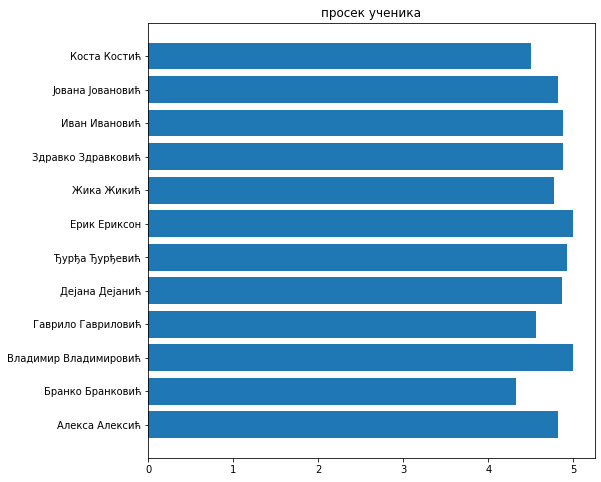

In [14]:
plt.figure(figsize=(8,8))
plt.barh(табела["име и презиме"], табела["просек"])
plt.title("просек ученика")
plt.show()
plt.close()

Представићемо сада и број оправданих и неоправданих изостанака сваког ученика.

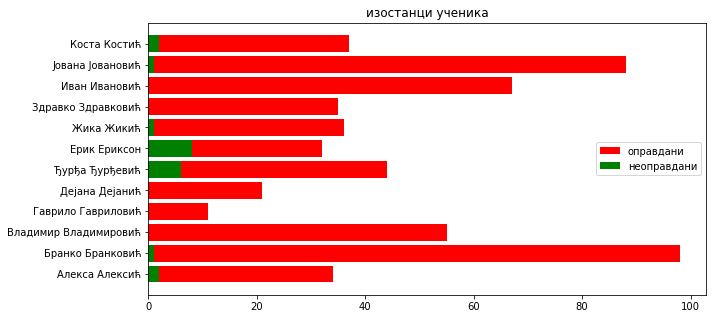

In [15]:
plt.figure(figsize=(10,5))
plt.barh(табела["име и презиме"], табела["оправдани"], color="r", label="оправдани")
plt.barh(табела["име и презиме"], табела["неоправдани"], color="g", label="неоправдани")
plt.title("изостанци ученика")
plt.legend()
plt.show()
plt.close()

### 15.3 Учитавање података из локалних CSV датотека

Из локалне датотеке учитаћемо податке о 30 најмногољуднијих земаља Европе.

In [16]:
import pandas as pd
популација = pd.read_csv("europetop30.csv")

Уз помоћ следеће команде можемо видети почетниј 5 врста табеле.

In [17]:
популација.head()

,rank,country,population
0,1,Russia,146024447
1,2,Turkey,84644753
2,3,Germany,83951077
3,4,France,65283211
4,5,United Kingdom,67960106


Не морамо да се ограничимо на само 5 врста, можемо изабрати колико их желимо на следећи начин:

In [18]:
популација.head(15)

,rank,country,population
0,1,Russia,146024447
1,2,Turkey,84644753
2,3,Germany,83951077
3,4,France,65283211
4,5,United Kingdom,67960106
5,6,Italy,60465251
6,7,Spain,46785134
7,8,Ukraine,43717532
8,9,Poland,37850596
9,10,Romania,19210031


Слично можемо видети и зачеље листе.

In [19]:
популација.tail(10)

,rank,country,population
20,21,Switzerland,8664280
21,22,Bulgaria,6943915
22,23,Serbia,8738786
23,24,Denmark,5793679
24,25,Finland,5542713
25,26,Slovakia,5461415
26,27,Norway,5424203
27,28,Ireland,4953657
28,29,Croatia,4101782
29,30,Georgia,3989981


Податке можемо представити и помоћу хистограма. Изабраћемо хоризонтални јер је у овом случају прегледнији.

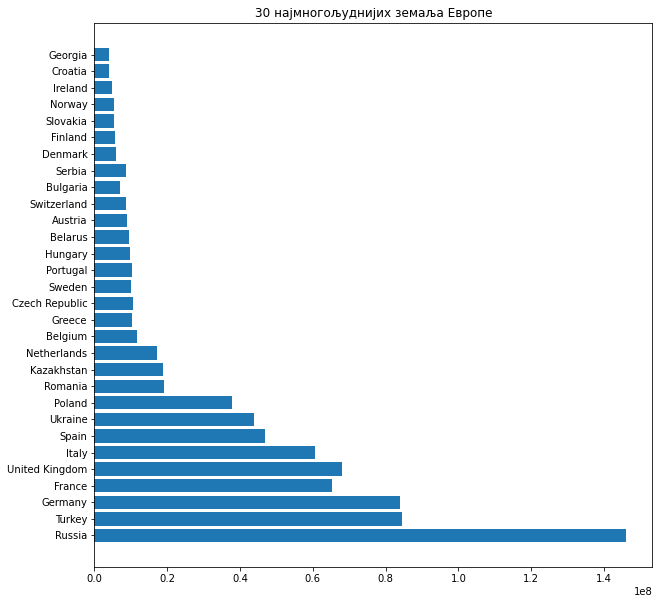

In [20]:
plt.figure(figsize=(10,10))
plt.barh(популација["country"], популација["population"])
plt.title("30 најмногољуднијих земаља Европе")
plt.show()
plt.close()

### 15.4 Учитавање података из удаљених ресурса

Табелу коју смо малопре имали можемо и да поставимо на неку веб локацију и да је одатле учитамо. 

In [21]:
a=pd.read_csv("https://raw.githubusercontent.com/petarzradovanovic/proba/master/europetop30.csv")
a.head(10)

,rank,country,population
0,1,Russia,146024447
1,2,Turkey,84644753
2,3,Germany,83951077
3,4,France,65283211
4,5,United Kingdom,67960106
5,6,Italy,60465251
6,7,Spain,46785134
7,8,Ukraine,43717532
8,9,Poland,37850596
9,10,Romania,19210031


Табелу можемо учитати и из неког другог извора који пронађемо, а који нам одговара.

Поред csv фајлова можемо обрађивати и html web странице и из њих извлачимо табеле. Битно је само да након адресе са које учитавамо, додамо у првој угластој загради шта ће нам бити заглавље табеле, а у другој да изаберемо коју по реду табелу са странице желимо да искористимо.

In [22]:
import requests

url = 'https://sr.wikipedia.org/wiki/%D0%A1%D0%B5%D1%80%D0%B8%D1%98%D0%B0_%D0%90'
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/128.0.0.0 Safari/537.36 Edg/128.0.0.0",
    "X-Requested-With": "XMLHttpRequest"
}

response = requests.get(url, headers=headers)
tables = pd.read_html(response.text, header=[0])
серија_а=tables[1]
серија_а.head()

,Клуб,Место,Стадион,Капацитет
0,Аталанта,Бергамо,Гевис стадион,21.747
1,Болоња,Болоња,Стадион Ренато Дал'Ара,36.462
2,Венеција,Венеција,Стадион Пјерлуиђи Пенцо,11.150
3,Верона,Верона,Стадион Маркантонио Бентегоди,39.371
4,Ђенова,Ђенова,Стадион Луиђи Ферарис,36.536


### Задаци

#### Задатак 1
У следећој ћелији се налазе подаци о највећим рекама у Србији. Од ових података треба направити табелу, а затим графички представити дужине река и површине њихових сливова.

In [25]:
реке=[["Дунав",2888,817000],
     ["Тиса",1026,157020],
     ["Сава",990,95719],
     ["Велика Морава",493,35419],
     ["Дрина",487,19570],
     ["Тамиш",359,13085],
     ["Дрим",335,11756],
     ["Јужна Морава",295,15469],
     ["Ибар",276,8059],
     ["Млава",263,17632]]
tabela_reka=pd.DataFrame(реке)
tabela_reka.columns=["Imena reka", "duzina reke","Povrsina reke"]

tabela_reka.head()

,Imena reka,duzina reke,Povrsina reke
0,Дунав,2888,817000
1,Тиса,1026,157020
2,Сава,990,95719
3,Велика Морава,493,35419
4,Дрина,487,19570


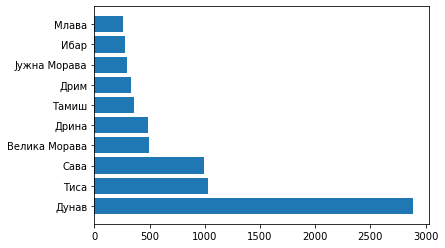

In [28]:
plt.barh(tabela_reka["Imena reka"],tabela_reka["duzina reke"])
plt.show()

#### Задатак 2

На веб адреси https://www.stat.gov.rs/sr-Latn/oblasti/obrazovanje/osnovno-obrazovanje налазе се подаци о броју ученика у основним школама приказани графички. Очитати податке са графика и представити их тако да се од њих може направити табела и направити табелу. Након тога графички приказати податке из табеле.

In [23]:
import requests

url = 'https://www.stat.gov.rs/sr-Latn/oblasti/obrazovanje/osnovno-obrazovanje'
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/128.0.0.0 Safari/537.36 Edg/128.0.0.0",
    "X-Requested-With": "XMLHttpRequest"
}

response = requests.get(url, headers=headers)
print(response.status_code)
print(response.text)
# table = pd.read_html(response.text, header=[0])
# obrazovanje=table[1]
# obrazovanje.head()

200

<!DOCTYPE html>
<html>
<head>
    <title>
		Osnovno obrazovanje  | Republički zavod za statistiku Srbije
	</title>
<!-- Standard fav icon -->
<link rel="shortcut icon" href="/images/favicon.ico" type="image/x-icon" />
<!-- Standard iPhone -->
<link rel="apple-touch-icon" sizes="57x57" href="/images/favicon-16x16.png" />
<!-- Retina iPhone --> 
<link rel="apple-touch-icon" sizes="114x114" href="/images/favicon-16x16.png" />
<!-- Standard iPad --> 
<link rel="apple-touch-icon" sizes="72x72" href="/images/favicon-16x16.png" />
<!-- Retina iPad --> 
<link rel="apple-touch-icon" sizes="144x144" href="/images/favicon-16x16.png" />

	<!-- Stara GA -->
 <!-- Google Analytics STARO!! -->
<script>
(function(i,s,o,g,r,a,m){i['GoogleAnalyticsObject']=r;i[r]=i[r]||function(){
(i[r].q=i[r].q||[]).push(arguments)},i[r].l=1*new Date();a=s.createElement(o),
m=s.getElementsByTagName(o)[0];a.async=1;a.src=g;m.parentNode.insertBefore(a,m)
})(window,document,'script','https://www.google-analytics.com/

#### Задатак 3
У наредној ћелији се налазе подаци о броју електричних возила у свету током година изражени у милионима. Направити од њих табелу и представити графички податке из табеле.

In [30]:
електрични_аутомобили=[[2019,4.79],
                       [2018,3.27],
                       [2017,1.93],
                       [2016,1.18],
                       [2015,0.72],
                       [2014,0.4],
                       [2013,0.22],
                       [2012,0.11]]

In [32]:
tabela = pd.DataFrame(електрични_аутомобили)
tabela.columns = ["godine", "broj vozila u milionima"]
tabela.tail ()

,godine,broj vozila u milionima
3,2016,1.18
4,2015,0.72
5,2014,0.40
6,2013,0.22
7,2012,0.11


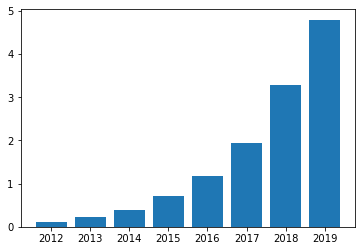

In [33]:
plt.bar(tabela["godine"],tabela["broj vozila u milionima"])
plt.show ()

#### Задатак 4
На сајту https://www.atptour.com/ налази се листа тренутно најбољих тенисера познатија као АТП листа. Направити csv фајл са подацима о 20 најбољих тенисера и учитати фајл. Од фајла направити табелу и графички представити бодове тенисера.

In [24]:
teniseri=pd.read_excel("ATP Lista.xlsx")
teniseri.head()

,Država,Teniser,Poeni
0,Španija,Carlos Alcaraz,13550
1,Italija,Jannik Sinner,11400
2,Srbija,Novak Đoković,5370
3,Nemačka,Alexander Zverev,4905
4,Italija,Lorenzo Musetti,4365


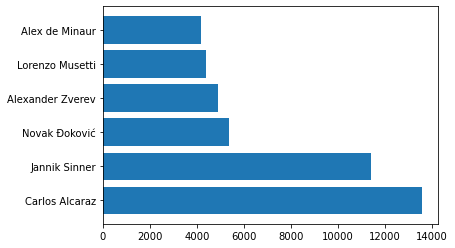

In [25]:
plt.barh(teniseri["Teniser"],teniseri["Poeni"])
plt.show()

#### Задатак 5
На сајту http://www.legaseriea.it/en налазе се подаци о италијанској фудбалској лиги. Пронаћи табелу и направити csv фајл са подацима из табеле. Након тога учитати фајл и направити табелу и графички приказ успеха тимова.

#### Задатак 6
Са линка https://raw.githubusercontent.com/petarzradovanovic/proba/master/vo%C4%87e.csv преузети фајл у коме се налазе подаци о кретању цена јабуке и крушке, формирати табелу и исцртати график који приказује кретање обе цене током датог периода.

#### Задатак 7
Са сајта https://sr.wikipedia.org/sr-el/Planinski_vrhovi_u_Srbiji_preko_2.000_metara учитати табелу висина највиших врхова у Србији помоћу функције за учитавање табеле из html фајла. Након тога издвојити 10 највиших врхова и представити их графички.